# 2D clinic Hamiltonian — elastic $H$ structure

Study the **3D elastic evolution Hamiltonian** from the clinic code, focusing on matrix structure before block encoding.

**Operator** (`_utility.FD_solver_3D_elastic`):
$$
H = i\,B^{-1/2} A\,B^{-1/2}, \qquad \dot\psi = -i H \psi.
$$

**Note:** there is no separate 2D elastic builder in `_utility.py`. This notebook uses **3D elastic** on a small grid with **thin $N_z$** (a quasi-2D $xy$ slice with minimal $z$ extent). That is the same staggered $(v,\sigma)$ formulation as the full clinic.

**State ordering** (`plot_elastic_3D`):
$$
\psi = [\,v_x \mid v_y \mid v_z \mid \sigma_{xx} \mid \sigma_{yy} \mid \sigma_{zz} \mid \sigma_{xy} \mid \sigma_{xz} \mid \sigma_{yz}\,].
$$

**Sections**
1. Build / verify $H$
2. Velocity–stress block structure
3. Pechan coefficient labeling
4. Verify labeling recovers $H$
5. $O_{\mathrm{data}}$ scaling
6. Split $B^{-1/2}$ vs $iA$ oracles
7. Staggered index oracles ($2\times 2\times 2$)
8. Assembled $U_H$ circuit (small grid)
9. Gate / depth table vs $N_s$
10. Small-grid $U_H$ content vs classical $H$
11. Time evolution (replace \texttt{MatrixExponential})
12. Larger-grid oracle correctness + sparse evolution (path A)

**Related notebooks**
- Scalar Poisson oracle (different matrix $G$): [`block_encoding_laplacian_2d_two_material.ipynb`](block_encoding_laplacian_2d_two_material.ipynb)
- 1D LCU basics: [`block_encoding_laplacian_1d.ipynb`](block_encoding_laplacian_1d.ipynb)

Helper modules: `_utility.py`, `_block_encoding_hamiltonian.py`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.getcwd()))
import importlib
import _block_encoding_hamiltonian as be_h
importlib.reload(be_h)
from _block_encoding_hamiltonian import (
    anti_hermitian_error,
    block_boundaries,
    build_hamiltonian_block_encoding_circuit,
    build_hamiltonian_oracle_labeling,
    build_minimal_hamiltonian_demo,
    clinic_elastic_materials,
    coefficient_labeling_table,
    compare_evolution_to_direct,
    compare_uh_to_classical,
    dense_matrix,
    diagonal_material_catalog,
    elastic_3d_layout,
    evolve_with_assembled_uh,
    hamiltonian_gate_budget_report,
    hermitian_error,
    imag_payload,
    label_coefficients_by_block,
    label_material_and_coupling,
    odata_budget_for_labeling,
    summarize_block_coupling,
    summarize_coefficient_labeling,
    summarize_hamiltonian_odata_scaling,
    summarize_sparse_circuit_scaling,
    run_larger_grid_oracle_and_sparse_evolution,
    summarize_uh_gate_scaling,
    summarize_uh_register_footprint,
    verify_labeling,
    verify_circuit_index_oracles,
    verify_staggered_index_oracles,
)
from _block_encoding_common import spectral_scale, transpiled_gate_counts, data_loading_subcircuit
from _utility import FD_solver_3D_elastic


## 1. Build clinic elastic $H$ and verify structure

Small 3D elastic grid ($N_x=N_y=4$, $N_z=2$) with clinic rock/fracture materials. We assemble $H$, $A$, $B$ via `FD_solver_3D_elastic`, check $A^\top \approx -A$ and $H^\dagger \approx H$, and plot the sparsity pattern with velocity/stress block boundaries.

In [2]:
NX, NY, NZ = 4, 4, 2
DX = DY = DZ = 0.05
BCS = {"L": "DBC", "R": "DBC", "T": "DBC", "B": "DBC", "F": "DBC", "Ba": "DBC"}

rho_model, S, fracture_mask = clinic_elastic_materials(NX, NY, NZ, add_fractures=True)
layout = elastic_3d_layout(NX, NY, NZ)

print("DOF layout [v | sigma]:")
for name, sl in layout.slices().items():
    print(f"  {name:10s}  indices {sl.start:4d}:{sl.stop:4d}  (size {sl.stop - sl.start})")
print(f"\nVelocity DOFs: {layout.n_vel}   Stress DOFs: {layout.n_stress}   Total N = {layout.n_total}")
print(f"Fracture cells: {fracture_mask.sum()} / {fracture_mask.size}")

H, A, B, B_sqrt, B_inv, B_inv_sqrt = FD_solver_3D_elastic(
    NX, NY, NZ, DX, DY, DZ, rho_model, S, BCS
)

print(f"\n|A + A^T|_max = {anti_hermitian_error(A):.2e}")
print(f"|H - H^dagger|_max = {hermitian_error(H):.2e}")
print(f"||H||_2 = {np.linalg.norm(dense_matrix(H), 2):.4g}")

DOF layout [v | sigma]:
  v_x         indices    0:  24  (size 24)
  v_y         indices   24:  48  (size 24)
  v_z         indices   48:  64  (size 16)
  sigma_xx    indices   64:  96  (size 32)
  sigma_yy    indices   96: 128  (size 32)
  sigma_zz    indices  128: 160  (size 32)
  sigma_xy    indices  160: 178  (size 18)
  sigma_xz    indices  178: 190  (size 12)
  sigma_yz    indices  190: 202  (size 12)

Velocity DOFs: 64   Stress DOFs: 138   Total N = 202
Fracture cells: 20 / 32

|A + A^T|_max = 0.00e+00
|H - H^dagger|_max = 2.91e-11
||H||_2 = 2.485e+05


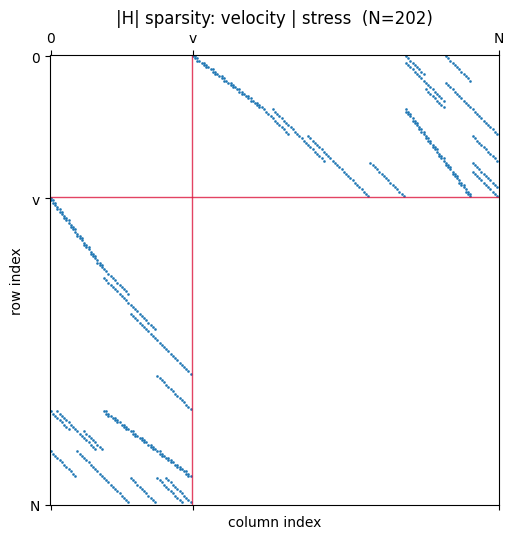

In [3]:
H_dense = dense_matrix(H)
ticks = block_boundaries(layout, coarse=True)
tick_labels = ["0", "v", "N"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.spy(np.abs(H_dense) > 0, markersize=0.8, color="C0")
for t in ticks[1:-1]:
    ax.axhline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
    ax.axvline(t - 0.5, color="crimson", lw=1.0, alpha=0.8)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("column index")
ax.set_ylabel("row index")
ax.set_title(f"|H| sparsity: velocity | stress  (N={layout.n_total})")
plt.tight_layout()
plt.show()

## 2. Block annotation: velocity–stress structure of $H$

The first-order elastic system matrix has the block layout (`compute_A_elastic_3D`)
$$
A = \begin{pmatrix} 0 & D \\ -D^\top & 0 \end{pmatrix},
$$
on $[v_x, v_y, v_z \mid \sigma_{xx}, \ldots, \sigma_{yz}]$, with $D$ the staggered divergence linking stress to velocity.

$B^{-1/2}$ is **block-diagonal** in the same ordering: density on velocity blocks, compliance on stress blocks. Fractures change local $B$ entries (and hence $H$) without changing the global block template.

Below: coarse velocity$\leftrightarrow$stress coupling, fine block table for $A$, and a zoom on one $D$ tile ($v_x \leftarrow \sigma_{xx}$).

In [4]:
def coupling_table(matrix, block_slices, label):
    rows = []
    for (row_name, col_name), (nnz, peak) in summarize_block_coupling(
        dense_matrix(matrix), block_slices
    ).items():
        rows.append({
            "matrix": label,
            "row_block": row_name,
            "col_block": col_name,
            "nnz": nnz,
            "max_abs": peak,
        })
    return pd.DataFrame(rows)

coarse = layout.coarse_slices()
df_coarse = coupling_table(H, coarse, "H")
display(df_coarse.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
))

df_fine = coupling_table(A, layout.slices(), "A")
pivot = df_fine.pivot_table(
    index="row_block", columns="col_block", values="nnz", fill_value=0
)
print("Nonzero counts in A (fine blocks):")
display(pivot.loc[["v_x", "v_y", "v_z"], [c for c in pivot.columns if c.startswith("sigma")]])

col_block,stress,velocity
row_block,,
stress,0.0,296.0
velocity,296.0,0.0


Nonzero counts in A (fine blocks):


col_block,sigma_xx,sigma_xy,sigma_xz,sigma_yy,sigma_yz,sigma_zz
row_block,,,,,,
v_x,48.0,36.0,24.0,0.0,0.0,0.0
v_y,0.0,36.0,0.0,48.0,24.0,0.0
v_z,0.0,0.0,24.0,0.0,24.0,32.0


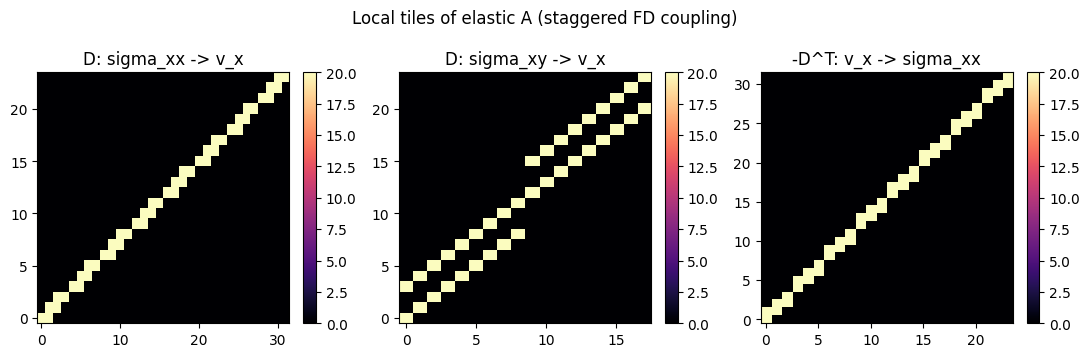

Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.


In [5]:
A_dense = dense_matrix(A)
vx_sl, sxx_sl = layout.vx_slice, layout.sxx_slice

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
panels = [
    ("D: sigma_xx -> v_x", A_dense[vx_sl, sxx_sl]),
    ("D: sigma_xy -> v_x", A_dense[vx_sl, layout.sxy_slice]),
    ("-D^T: v_x -> sigma_xx", A_dense[sxx_sl, vx_sl]),
]
for ax, (title, block) in zip(axes, panels):
    im = ax.imshow(np.abs(block), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Local tiles of elastic A (staggered FD coupling)")
plt.tight_layout()
plt.show()

print("Takeaway: H is block-sparse with velocity-stress coupling; not a scalar 5-point Laplacian.")

In [6]:
# Homogeneous vs fractured H: which block tiles change?
rho_homo, S_homo, _ = clinic_elastic_materials(NX, NY, NZ, add_fractures=False)
H_homo, *_ = FD_solver_3D_elastic(NX, NY, NZ, DX, DY, DZ, rho_homo, S_homo, BCS)

base = summarize_block_coupling(dense_matrix(H_homo), coarse)
frac = summarize_block_coupling(dense_matrix(H), coarse)
changed = [
    key for key in base
    if base[key][0] != frac[key][0]
    or not np.isclose(base[key][1], frac[key][1])
]
print(f"Coarse tiles changed by fractures: {changed}")


Coarse tiles changed by fractures: [('velocity', 'stress'), ('stress', 'velocity')]


## 3. Label distinct coefficients per block (oracle design)

Pechan-style relabeling for $H$: each nonzero entry belongs to a **block section**
$(\text{row\_block}, \text{col\_block})$.  Distinct values within a section get
$d_{\mathrm{val}}$; the section index is $d_{\mathrm{ind}}$, so
$$
d = d_{\mathrm{ind}}\,\|\, d_{\mathrm{val}}.
$$
The same magnitude in different sections receives **different** $d$ labels (needed for $O_{\mathrm{data}}$).

We also catalog diagonal **material** coefficients in $B^{-1/2}$ per block — the natural split before encoding $iA$ and $B^{-1/2}$ separately.

In [7]:
labeling_H = label_coefficients_by_block(H, layout, matrix_name="H")
summary_H = summarize_coefficient_labeling(labeling_H)

print(f"H: D' = {summary_H['D_prime']} distinct labels  (D_padded = {summary_H['D_padded']})")
print(f"    sections = {summary_H['n_sections']},  d_ind bits = {summary_H['d_ind_bits']},  d_val bits = {summary_H['d_val_bits']}")
print(f"    n_d qubits ~ {summary_H['n_d_qubits']}")

display(coefficient_labeling_table(labeling_H))

H: D' = 96 distinct labels  (D_padded = 256)
    sections = 18,  d_ind bits = 5,  d_val bits = 3
    n_d qubits ~ 8


,section,n_distinct,matrix
0,sigma_xx -> v_x,8,H
1,sigma_xy -> v_x,6,H
2,sigma_xy -> v_y,8,H
3,sigma_xz -> v_x,4,H
4,sigma_xz -> v_z,6,H
5,sigma_yy -> v_y,4,H
6,sigma_yz -> v_y,4,H
7,sigma_yz -> v_z,4,H
8,sigma_zz -> v_z,4,H
9,v_x -> sigma_xx,8,H


In [8]:
# Coupling sections (velocity <-> stress) carry fracture-induced coefficient variety
coupling_sections = [
    row for row in summary_H["distinct_values_per_section"]
    if ("v_" in row.split(" -> ")[0] and "sigma" in row.split(" -> ")[1])
    or ("sigma" in row.split(" -> ")[0] and "v_" in row.split(" -> ")[1])
]
rows = []
for section in coupling_sections:
    vals = summary_H["section_values"][section]
    rows.append({
        "section": section,
        "n_distinct": len(vals),
        "sample": [f"{v.real:.4g}" for v in vals[:4]],
    })
display(pd.DataFrame(rows))

material_df = diagonal_material_catalog(B_inv_sqrt, layout)
print("\nDiagonal B^{-1/2} material catalog (per block):")
display(material_df[["block", "n_dof", "n_distinct"]])

,section,n_distinct,sample
0,sigma_xx -> v_x,8,"[0, 0, 0, 0]"
1,sigma_xy -> v_x,6,"[0, 0, 0, 0]"
2,sigma_xy -> v_y,8,"[0, 0, 0, 0]"
3,sigma_xz -> v_x,4,"[0, 0, 0, 0]"
4,sigma_xz -> v_z,6,"[0, 0, 0, 0]"
5,sigma_yy -> v_y,4,"[0, 0, 0, 0]"
6,sigma_yz -> v_y,4,"[0, 0, 0, 0]"
7,sigma_yz -> v_z,4,"[0, 0, 0, 0]"
8,sigma_zz -> v_z,4,"[0, 0, 0, 0]"
9,v_x -> sigma_xx,8,"[0, 0, 0, 0]"



Diagonal B^{-1/2} material catalog (per block):


,block,n_dof,n_distinct
0,v_x,24,3
1,v_y,24,2
2,v_z,16,2
3,sigma_xx,32,2
4,sigma_yy,32,2
5,sigma_zz,32,2
6,sigma_xy,18,3
7,sigma_xz,12,2
8,sigma_yz,12,2


In [9]:
# Homogeneous vs fractured: how label count scales
labeling_homo = label_coefficients_by_block(H_homo, layout, matrix_name="H_homo")

rows = []
for name, labeling in [("fractured", labeling_H), ("homogeneous", labeling_homo)]:
    s = summarize_coefficient_labeling(labeling)
    rows.append({
        "case": name,
        "D_prime": s["D_prime"],
        "n_sections": s["n_sections"],
        "max_distinct_in_section": max(s["distinct_values_per_section"].values()),
    })
display(pd.DataFrame(rows))

,case,D_prime,n_sections,max_distinct_in_section
0,fractured,96,18,8
1,homogeneous,36,18,2


## 4. Verify labeling recovers $H$

Rebuild $H$ from Pechan labels / value table and check entrywise agreement (same role as Section 4 in the Laplacian notebook).

In [10]:
check = verify_labeling(labeling_H, H)
print("Labeling verification:", check)
assert check["max_abs_error"] < 1e-10
assert check["nnz_mask_mismatches"] == 0

# Purely imaginary Hermitian: Re(H)=0 so O_data loads Im(H)
H_dense_check = dense_matrix(H)
print(f"max|Re(H)| = {np.max(np.abs(H_dense_check.real)):.2e}")
print(f"max|Im(H)| = {np.max(np.abs(H_dense_check.imag)):.4g}")


Labeling verification: {'max_abs_error': 3.4022144910356156e-13, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
max|Re(H)| = 0.00e+00
max|Im(H)| = 1.333e+05


## 5. $O_{\mathrm{data}}$ scaling with grid size

Fast sweep of $D'$ and transpiled $O_{\mathrm{data}}$ depth/size on `Im(H)` (clinic $H$ is purely imaginary). Uses `summarize_hamiltonian_odata_scaling` — no index-oracle assembly. Set `sk_t_count=True` only if you need Solovay–Kitaev T-gates.

,nx,ny,nz,N,D_prime,D_padded,n_sections,n_d_qubits,O_data_depth,O_data_size,O_data_t_gates,alpha_Im
0,2,2,2,42,64,128,18,7,19068,20843,4826,156029.686784
1,4,2,2,92,96,256,18,8,42843,57598,21440,219391.613924
2,4,4,2,202,96,256,18,8,42843,57598,21440,248511.586832


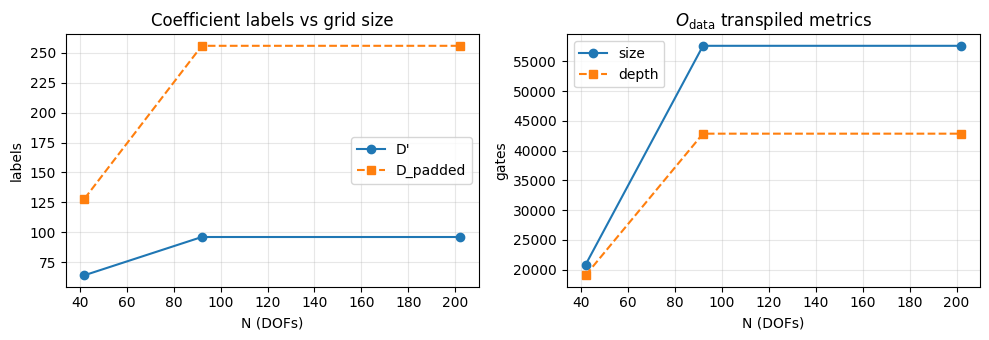

In [11]:
odata_scale = summarize_hamiltonian_odata_scaling(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=True,
    sk_t_count=False,
)
display(odata_scale)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(odata_scale["N"], odata_scale["D_prime"], "o-", label="D'")
ax[0].plot(odata_scale["N"], odata_scale["D_padded"], "s--", label="D_padded")
ax[0].set_xlabel("N (DOFs)")
ax[0].set_ylabel("labels")
ax[0].set_title("Coefficient labels vs grid size")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(odata_scale["N"], odata_scale["O_data_size"], "o-", label="size")
ax[1].plot(odata_scale["N"], odata_scale["O_data_depth"], "s--", label="depth")
ax[1].set_xlabel("N (DOFs)")
ax[1].set_ylabel("gates")
ax[1].set_title(r"$O_{\mathrm{data}}$ transpiled metrics")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Split $B^{-1/2}$ vs $iA$ oracles (physics-faithful encoding)

Clinic evolution uses
$$
H = i\,B^{-1/2} A\,B^{-1/2}.
$$
Label and budget **material** ($B^{-1/2}$, diagonal) and **coupling** ($iA$) separately, then verify the product reconstitutes $H$.

In [12]:
factors = label_material_and_coupling(A, B_inv_sqrt, layout)
print("iA:", {k: factors["summary_iA"][k] for k in ("D_prime", "D_padded", "n_sections", "n_d_qubits")})
print("B_inv_sqrt:", {k: factors["summary_B_inv_sqrt"][k] for k in ("D_prime", "D_padded", "n_sections", "n_d_qubits")})
print("verify iA:", factors["verify_iA"])
print("verify B_inv_sqrt:", factors["verify_B_inv_sqrt"])

product_err = np.max(np.abs(dense_matrix(H) - factors["H_from_factors"]))
print(f"|H - i B^{{-1/2}} A B^{{-1/2}}|_max = {product_err:.2e}")
assert product_err < 1e-10

budgets = pd.DataFrame(
    [
        {"operator": "H", **{k: odata_budget_for_labeling(labeling_H, sk_t_count=False)[k] for k in ("alpha", "depth", "size", "t_gates")}},
        {"operator": "iA", **{k: odata_budget_for_labeling(factors["labeling_iA"], sk_t_count=False)[k] for k in ("alpha", "depth", "size", "t_gates")}},
        {
            "operator": "B_inv_sqrt",
            **{
                k: odata_budget_for_labeling(factors["labeling_B_inv_sqrt"], use_imag=False, sk_t_count=False)[k]
                for k in ("alpha", "depth", "size", "t_gates")
            },
        },
    ]
)
display(budgets)
display(factors["material_catalog"][["block", "n_dof", "n_distinct"]])


iA: {'D_prime': 36, 'D_padded': 64, 'n_sections': 18, 'n_d_qubits': 6}
B_inv_sqrt: {'D_prime': 20, 'D_padded': 64, 'n_sections': 9, 'n_d_qubits': 6}
verify iA: {'max_abs_error': 0.0, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
verify B_inv_sqrt: {'max_abs_error': 3.7925153469065e-13, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}
|H - i B^{-1/2} A B^{-1/2}|_max = 0.00e+00


,operator,alpha,depth,size,t_gates
0,H,248511.586832,42843,57598,21440
1,iA,76.436357,4043,7128,0
2,B_inv_sqrt,286644.838010,4043,7128,0


,block,n_dof,n_distinct
0,v_x,24,3
1,v_y,24,2
2,v_z,16,2
3,sigma_xx,32,2
4,sigma_yy,32,2
5,sigma_zz,32,2
6,sigma_xy,18,3
7,sigma_xz,12,2
8,sigma_yz,12,2


## 7. Staggered index oracles on a minimal grid

On $2\times 2\times 2$ (homogeneous, $N=42$), build Pechan-style $(d,m)\to(i,j)$ maps and lookup $O_c$, $O_r$ for the staggered elastic layout. Index register is padded to a power of two (clinic DOF counts are not powers of two).

**Why not $4\times 4\times 2$ here?** Classical $(d,m)\to(i,j)$ maps still work on larger grids. Sections 8–11 need the **real MCX** circuits $O_c$, $O_r$, $U_H$ on the same `oracle`. Building those circuits is cheap; **classically simulating / checking** them is not: a full statevector of $O_c$ already takes $\sim 10\,\mathrm{s}$ on $2\times 2\times 2$ (14 lookup qubits) and extrapolates to minutes–hours on $4\times 2\times 2$ / $4\times 4\times 2$. The next cells separate (i) dense-matrix RAM and (ii) this sparse-circuit simulation cost.


In [13]:
demo = build_minimal_hamiltonian_demo(2, 2, 2, add_fractures=False)
oracle = demo["oracle"]
oracle_check = demo["oracle_check"]

print("Minimal-grid layout: N =", demo["layout"].n_total)
print("Oracle registers: n_d =", oracle.n_d_qubits, ", n_m =", oracle.n_m_qubits, ", n_idx =", oracle.n_index_qubits)
print("Full U_H qubit count (data|d|m|idx):", oracle.num_qubits_uh)
print("Oracle check:", oracle_check)
assert oracle_check["ok"]

print("verify H on minimal grid:", demo["verify_H"])
assert demo["verify_H"]["max_abs_error"] < 1e-10


Minimal-grid layout: N = 42
Oracle registers: n_d = 6 , n_m = 2 , n_idx = 6
Full U_H qubit count (data|d|m|idx): 15
Oracle check: {'n_entries': 96, 'duplicates': 0, 'missing_nnz': 0, 'extra_coverage': 0, 'oracle_chain_errors': 0, 'n_d_qubits': 6, 'n_m_qubits': 2, 'n_index_qubits': 6, 'num_qubits_uh': 15, 'ok': True}
verify H on minimal grid: {'max_abs_error': 0.0, 'nnz_mask_mismatches': 0.0, 'value_table_error': 0.0}


,nx,ny,nz,N_s,n_d,n_m,n_idx,n_qubits_uh,lookup_dim,dense_Oc_GB,dense_UH_GB,dense_lookup_ok
0,2,2,2,42,6,2,6,15,16384,4.0,16.0,False
1,4,2,2,92,6,4,7,18,131072,256.0,1020.0,False
2,4,4,2,202,6,5,8,20,524288,4100.0,16400.0,False


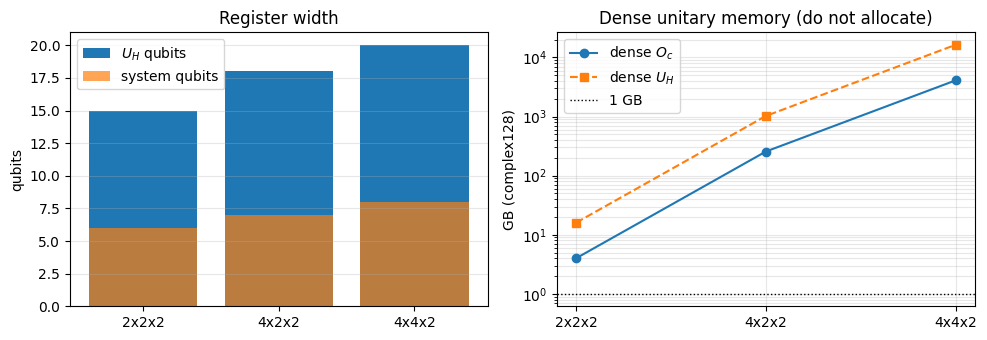

Dense story (already covered): 2x2x2 needs ~4.0 GB for dense O_c (16384-dim); 4x4x2 is ~4096 GB.
Next cell: why 2x2x2 is still required for *sparse* / real MCX O_c, O_r, U_H on a laptop.


In [14]:
# Why 2x2x2: register footprint vs larger grids (homogeneous, matches circuit demos)
uh_footprint = summarize_uh_register_footprint(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=False,
)
cols = [
    "nx", "ny", "nz", "N_s", "n_d", "n_m", "n_idx", "n_qubits_uh",
    "lookup_dim", "dense_Oc_GB", "dense_UH_GB", "dense_lookup_ok",
]
show = uh_footprint[cols].copy()
show["dense_Oc_GB"] = show["dense_Oc_GB"].map(lambda v: float(f"{v:.3g}"))
show["dense_UH_GB"] = show["dense_UH_GB"].map(lambda v: float(f"{v:.3g}"))
display(show)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
labels = [f"{r.nx}x{r.ny}x{r.nz}" for r in uh_footprint.itertuples()]
x = range(len(labels))
ax[0].bar(x, uh_footprint["n_qubits_uh"], color="C0", label=r"$U_H$ qubits")
ax[0].bar(x, uh_footprint["n_system"], color="C1", alpha=0.7, label="system qubits")
ax[0].set_xticks(list(x), labels)
ax[0].set_ylabel("qubits")
ax[0].legend()
ax[0].grid(True, axis="y", alpha=0.3)
ax[0].set_title("Register width")

ax[1].semilogy(list(x), uh_footprint["dense_Oc_GB"], "o-", label=r"dense $O_c$")
ax[1].semilogy(list(x), uh_footprint["dense_UH_GB"], "s--", label=r"dense $U_H$")
ax[1].axhline(1.0, color="k", ls=":", lw=1, label="1 GB")
ax[1].set_xticks(list(x), labels)
ax[1].set_ylabel("GB (complex128)")
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)
ax[1].set_title("Dense unitary memory (do not allocate)")
plt.tight_layout()
plt.show()

row22 = uh_footprint.iloc[0]
print(
    f"Dense story (already covered): 2x2x2 needs ~{row22['dense_Oc_GB']:.1f} GB for dense O_c "
    f"({int(row22['lookup_dim'])}-dim); 4x4x2 is ~{uh_footprint.iloc[-1]['dense_Oc_GB']:.0f} GB."
)
print("Next cell: why 2x2x2 is still required for *sparse* / real MCX O_c, O_r, U_H on a laptop.")


,nx,ny,nz,N_s,nnz,n_lookup,n_qubits_uh,O_c_size,O_r_size,U_H_size_decomposed,est_O_c_sv_seconds
0,2,2,2,42,96,14,15,216,244,940,11.00000
1,4,2,2,92,240,17,18,702,664,1846,286.00000
2,4,4,2,202,592,19,20,2107,2186,4773,3433.62963


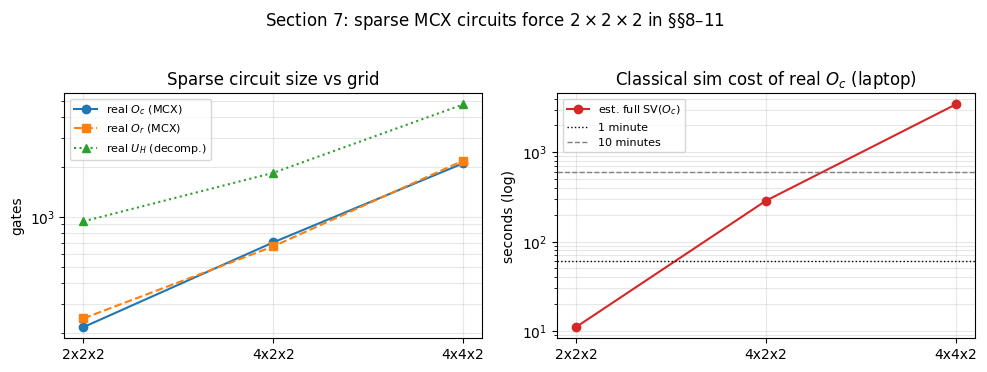

Takeaway (sparse): full Statevector(O_c) ~11s on 2x2x2 (14 lookup qubits, 216 MCX), ~5 min on 4x2x2, ~57 min on 4x4x2 — impractical for interactive §§8–11 demos.
Building the circuits alone stays cheap; the wall is classical simulation of the real MCX oracles / U_H on the padded lookup register.


In [15]:
# Why 2x2x2 for *sparse* / real MCX circuits (laptop classical simulation)
# Building O_c / O_r / U_H is cheap on 4x4x2; full Statevector(O_c) is not.
sparse_scale = summarize_sparse_circuit_scaling(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=False,
    reference_sv_seconds=11.0,  # measured full Statevector(O_c) on 2x2x2
)
display(
    sparse_scale[
        [
            "nx", "ny", "nz", "N_s", "nnz", "n_lookup", "n_qubits_uh",
            "O_c_size", "O_r_size", "U_H_size_decomposed",
            "est_O_c_sv_seconds",
        ]
    ]
)

labels = [f"{r.nx}x{r.ny}x{r.nz}" for r in sparse_scale.itertuples()]
x = list(range(len(labels)))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(x, sparse_scale["O_c_size"], "o-", label=r"real $O_c$ (MCX)")
ax[0].plot(x, sparse_scale["O_r_size"], "s--", label=r"real $O_r$ (MCX)")
ax[0].plot(x, sparse_scale["U_H_size_decomposed"], "^:", label=r"real $U_H$ (decomp.)")
ax[0].set_xticks(x, labels)
ax[0].set_ylabel("gates")
ax[0].set_yscale("log")
ax[0].legend(fontsize=8)
ax[0].grid(True, which="both", alpha=0.3)
ax[0].set_title("Sparse circuit size vs grid")

ax[1].semilogy(x, sparse_scale["est_O_c_sv_seconds"], "o-", color="C3", label=r"est. full SV($O_c$)")
ax[1].axhline(60.0, color="k", ls=":", lw=1, label="1 minute")
ax[1].axhline(600.0, color="gray", ls="--", lw=1, label="10 minutes")
ax[1].set_xticks(x, labels)
ax[1].set_ylabel("seconds (log)")
ax[1].legend(fontsize=8)
ax[1].grid(True, which="both", alpha=0.3)
ax[1].set_title(r"Classical sim cost of real $O_c$ (laptop)")
fig.suptitle("Section 7: sparse MCX circuits force $2\\times2\\times2$ in §§8–11", y=1.02)
plt.tight_layout()
plt.show()

r22, r42, r44 = sparse_scale.iloc[0], sparse_scale.iloc[1], sparse_scale.iloc[-1]
print(
    f"Takeaway (sparse): full Statevector(O_c) ~{r22['est_O_c_sv_seconds']:.0f}s on 2x2x2 "
    f"({int(r22['n_lookup'])} lookup qubits, {int(r22['O_c_size'])} MCX), "
    f"~{r42['est_O_c_sv_seconds']/60:.0f} min on 4x2x2, "
    f"~{r44['est_O_c_sv_seconds']/60:.0f} min on 4x4x2 — impractical for interactive §§8–11 demos."
)
print(
    f"Building the circuits alone stays cheap; the wall is classical simulation of "
    f"the real MCX oracles / U_H on the padded lookup register."
)


## 8. Assembled block-encoding circuit $U_H$ (small grid)

Same Pechan / Sünderhauf assembly as the Laplacian notebook (`O_c^{-1} \cdot O_{\mathrm{data}} \cdot Z \cdot O_t \cdot O_r` on `data | d | m | idx`), but for clinic elastic $\mathrm{Im}(H)$.

**Index oracles are real circuits** (default `materialize_lookup="circuit"`): controlled-XOR / MCX implementations of
$O_c:\,|d\,m\,0\rangle\mapsto|d\,m\,j\rangle$, $O_r:\,|d\,m\,j\rangle\mapsto|d\,m\,i\rangle$, and $O_t$ (high-$m$ bit flip). This avoids dense $2^{14}\times 2^{14}$ unitaries while still using the staggered $(d,m)\to(i,j)$ maps from Section 7.

Use `materialize_lookup="opaque"` for fast scaling sweeps, or `"dense"` only on toy registers.


In [16]:
circuit_uh, alpha_uh = build_hamiltonian_block_encoding_circuit(
    oracle, materialize_lookup="circuit"
)
print(f"U_H: {circuit_uh.num_qubits} qubits, depth {circuit_uh.depth()}, size {circuit_uh.size()}")
print(f"alpha = ||Im(H)||_2 = {alpha_uh:.4g}")
print(f"top-level ops: {dict(circuit_uh.count_ops())}\n")
print(circuit_uh.draw(output="text", fold=-1))

# Real MCX index oracles vs Section 7 maps
circuit_chk = verify_circuit_index_oracles(oracle)
print("\nCircuit index-oracle check:", circuit_chk)
assert circuit_chk["ok"]

budget_uh = hamiltonian_gate_budget_report(oracle, materialize_lookup="opaque")
print("\nO_data transpiled counts:")
for key in ("depth", "size", "t_gates"):
    print(f"  {key}: {budget_uh['O_data'][key]}")


U_H: 15 qubits, depth 66, size 68
alpha = ||Im(H)||_2 = 2.521e+05
top-level ops: {'O_c_dg': 1, 'ry': 1, 'c6circuit-37160_o1': 1, 'c6circuit-37169_o2': 1, 'c6circuit-37178_o3': 1, 'c6circuit-37187_o4': 1, 'c6circuit-37196_o5': 1, 'c6circuit-37205_o6': 1, 'c6circuit-37214_o7': 1, 'c6circuit-37223_o8': 1, 'c6circuit-37232_o9': 1, 'c6circuit-37241_o10': 1, 'c6circuit-37250_o11': 1, 'c6circuit-37259_o12': 1, 'c6circuit-37268_o13': 1, 'c6circuit-37277_o14': 1, 'c6circuit-37286_o15': 1, 'c6circuit-37295_o16': 1, 'c6circuit-37304_o17': 1, 'c6circuit-37313_o18': 1, 'c6circuit-37322_o19': 1, 'c6circuit-37331_o20': 1, 'c6circuit-37340_o21': 1, 'c6circuit-37349_o22': 1, 'c6circuit-37358_o23': 1, 'c6circuit-37367_o24': 1, 'c6circuit-37376_o25': 1, 'c6circuit-37385_o26': 1, 'c6circuit-37394_o27': 1, 'c6circuit-37403_o28': 1, 'c6circuit-37412_o29': 1, 'c6circuit-37421_o30': 1, 'c6circuit-37430_o31': 1, 'c6circuit-37439_o32': 1, 'c6circuit-37448_o33': 1, 'c6circuit-37457_o34': 1, 'c6circuit-37466_o35'

U_H with real index oracles (as drawn): depth=66, size=68
Decomposed index oracles: O_c size=216, O_r size=244, O_t size=36
Dense O_c would be 16384 x 16384 (~4.0 GB) — not allocated.


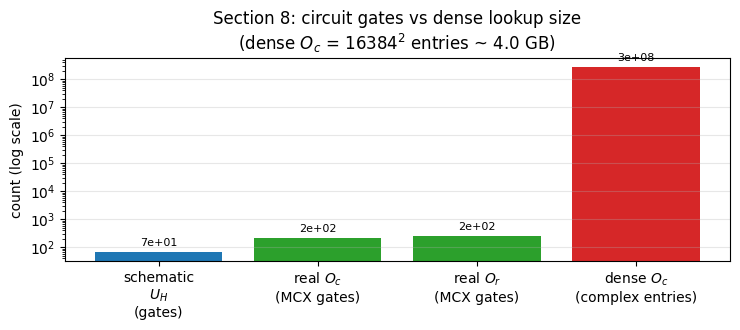

Dense O_c has 1.24e+06x more entries than MCX gates in real O_c.
=== O_c decomposed (first 40 lines) ===
      ┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐                                                                                                                                                                               ┌───┐          ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐                                                                                                                                                                               ┌───┐          ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐                                                                               

In [17]:
# Real MCX oracles vs opaque schematic vs dense unitary memory
from _block_encoding_hamiltonian import (
    build_column_oracle_circuit,
    build_row_oracle_circuit,
    build_transpose_oracle_circuit,
)

oc_circ = build_column_oracle_circuit(oracle)
or_circ = build_row_oracle_circuit(oracle)
ot_circ = build_transpose_oracle_circuit(oracle)
fp = uh_footprint.set_index(["nx", "ny", "nz"]).loc[(2, 2, 2)]

print(
    f"U_H with real index oracles (as drawn): depth={circuit_uh.depth()}, "
    f"size={circuit_uh.size()}"
)
print(
    f"Decomposed index oracles: O_c size={oc_circ.size()}, "
    f"O_r size={or_circ.size()}, O_t size={ot_circ.size()}"
)
print(
    f"Dense O_c would be {int(fp['lookup_dim'])} x {int(fp['lookup_dim'])} "
    f"(~{fp['dense_Oc_GB']:.1f} GB) — not allocated."
)

lookup_dim = int(fp["lookup_dim"])
dense_oc_elems = lookup_dim * lookup_dim  # complex entries if materialized

modes = [
    "schematic\n$U_H$\n(gates)",
    "real $O_c$\n(MCX gates)",
    "real $O_r$\n(MCX gates)",
    "dense $O_c$\n(complex entries)",
]
vals = [circuit_uh.size(), oc_circ.size(), or_circ.size(), dense_oc_elems]
colors = ["C0", "C2", "C2", "C3"]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(modes, vals, color=colors)
ax.set_yscale("log")
ax.set_ylabel("count (log scale)")
ax.set_title(
    "Section 8: circuit gates vs dense lookup size\n"
    f"(dense $O_c$ = {lookup_dim}$^2$ entries ~ {fp['dense_Oc_GB']:.1f} GB)"
)
ax.grid(True, axis="y", alpha=0.3)
ax.bar_label(bars, labels=[f"{v:.0g}" for v in vals], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"Dense O_c has {dense_oc_elems / oc_circ.size():.2e}x more entries than MCX gates in real O_c."
)

# Decompose a subcircuit to expose MCX layers (Qiskit)
print("=== O_c decomposed (first 40 lines) ===")
print("\n".join(str(oc_circ.decompose().draw(output="text", fold=-1)).splitlines()[:40]))
print("\nTip: circuit_uh.decompose(reps=1) expands O_c/O_r/O_t; reps=2 also expands O_data Ry boxes.")


## 9. Gate / depth table vs $N_s$

Sweep clinic grid size at fixed fracture geometry. Reports transpiled $O_{\mathrm{data}}$ and $U_H$ depth/size with **real MCX index oracles** (`materialize_lookup="circuit"`). `U_H_size` is the schematic top-level count; `U_H_size_decomposed` expands $O_c$, $O_r$, $O_t$ once. Set `sk_t_count=True` for Solovay–Kitaev T-counts on $O_{\mathrm{data}}$ only.

**Reading tip:** $O_{\mathrm{data}}$ tracks $D'$ (heterogeneity). Schematic $U_H$ size stays $\mathcal{O}(10^2)$ gates, but decomposed $U_H$ and `dense_Oc_GB` grow quickly — compare Section 7 footprint to see why full lookup synthesis still forces the $2\times2\times2$ demo.


,nx,ny,nz,N_s,D_prime,D_padded,n_qubits_uh,alpha_Im,O_data_depth,O_data_size,O_data_t_gates,U_H_depth,U_H_size,U_H_size_decomposed,U_H_depth_decomposed
0,2,2,2,42,64,128,16,156029.686784,19068,20843,4826,130,132,1542,903
1,4,2,2,92,96,256,19,219391.613924,42843,57598,21440,258,260,3758,2224
2,4,4,2,202,96,256,21,248511.586832,42843,57598,21440,258,260,6685,5151


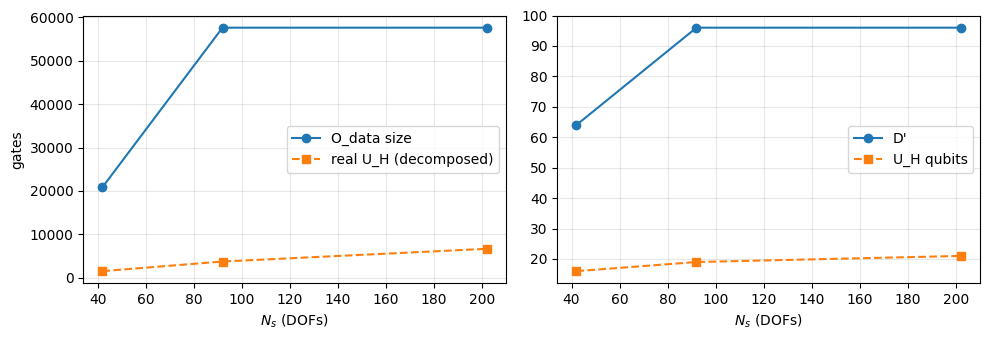

In [18]:
uh_scale = summarize_uh_gate_scaling(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=True,
    sk_t_count=False,
    materialize_lookup="circuit",
)
display(uh_scale)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(uh_scale["N_s"], uh_scale["O_data_size"], "o-", label="O_data size")
ax[0].plot(uh_scale["N_s"], uh_scale["U_H_size_decomposed"], "s--", label="real U_H (decomposed)")
ax[0].set_xlabel(r"$N_s$ (DOFs)")
ax[0].set_ylabel("gates")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(uh_scale["N_s"], uh_scale["D_prime"], "o-", label="D'")
ax[1].plot(uh_scale["N_s"], uh_scale["n_qubits_uh"], "s--", label="U_H qubits")
ax[1].set_xlabel(r"$N_s$ (DOFs)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,nx,ny,nz,N_s,D_prime,O_data_size,U_H_size_decomposed,dense_Oc_GB,n_qubits_uh
0,2,2,2,42,64,20843,1542,16.0,16
1,4,2,2,92,96,57598,3758,1024.0,19
2,4,4,2,202,96,57598,6685,16384.0,21


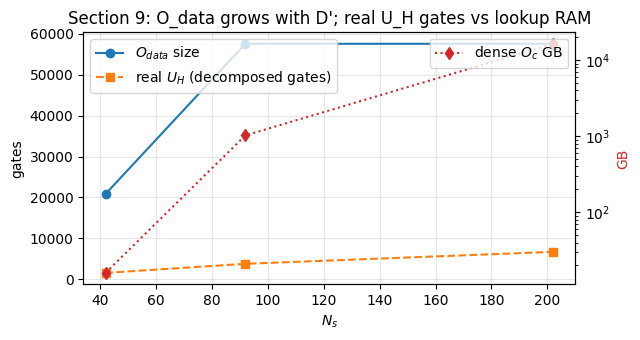

In [19]:
# Overlay: real (decomposed) U_H gate count vs dense O_c memory
fp_frac = summarize_uh_register_footprint(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=True,
)
merged = uh_scale.merge(
    fp_frac[["nx", "ny", "nz", "dense_Oc_GB", "lookup_dim", "n_qubits_uh"]],
    on=["nx", "ny", "nz"],
    suffixes=("", "_fp"),
)
display(merged[["nx", "ny", "nz", "N_s", "D_prime", "O_data_size", "U_H_size_decomposed", "dense_Oc_GB", "n_qubits_uh"]])

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(merged["N_s"], merged["O_data_size"], "o-", label=r"$O_{data}$ size")
ax.plot(merged["N_s"], merged["U_H_size_decomposed"], "s--", label=r"real $U_H$ (decomposed gates)")
ax.set_xlabel(r"$N_s$")
ax.set_ylabel("gates")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.semilogy(merged["N_s"], merged["dense_Oc_GB"], "d:", color="C3", label=r"dense $O_c$ GB")
ax2.set_ylabel("GB", color="C3")
ax2.legend(loc="upper right")
ax.set_title("Section 9: O_data grows with D'; real U_H gates vs lookup RAM")
plt.tight_layout()
plt.show()


## 10. Small-grid $U_H$ content vs classical $H$

A dense $2^{15}\times 2^{15}$ unitary is too large to materialize. Following the Laplacian notebook’s `verify_block_encoding` path, we verify **oracle content**:

1. classical reconstruction of $\mathrm{Im}(H)/\alpha$ from $(d,m)\to(i,j)$;
2. index-oracle chain $O_r\,O_c\,|d\,m\,0\rangle = |d\,m\,i\rangle$;
3. $O_{\mathrm{data}}$ amplitudes $|v_d|/\alpha$.

Clinic $H$ is purely imaginary Hermitian, so the encoded real payload is $\mathrm{Im}(H)$.

The illustration below contrasts Hilbert-space sizes: content checks use nnz / small $O_{\mathrm{data}}$ operators, not the full $U_H$ matrix — which is why $2\times2\times2$ is still required if you wanted a dense unitary test, but not for this verification path.


In [20]:
uh_cmp = compare_uh_to_classical(oracle)
display(pd.DataFrame([uh_cmp]))

assert uh_cmp["classical_recon_error"] < 1e-10
assert uh_cmp["index_oracle_ok"] == 1.0
assert uh_cmp["odata_amp_error"] < 1e-10

print(
    f"U_H content OK on 2x2x2: recon err = {uh_cmp['classical_recon_error']:.2e}, "
    f"O_data amp err = {uh_cmp['odata_amp_error']:.2e}, "
    f"registers = {int(uh_cmp['num_qubits_uh'])} qubits"
)

# Factor split also holds on the minimal grid
f_err = np.max(np.abs(dense_matrix(demo["H"]) - demo["factors"]["H_from_factors"]))
print(f"minimal-grid |H - i B^{{-1/2}} A B^{{-1/2}}|_max = {f_err:.2e}")
assert f_err < 1e-10


,alpha,classical_recon_error,index_oracle_ok,odata_amp_error,num_qubits_uh,n_d_qubits,n_m_qubits,n_index_qubits
0,252081.85805,0.0,1.0,2.864375e-14,15.0,6.0,2.0,6.0


U_H content OK on 2x2x2: recon err = 0.00e+00, O_data amp err = 2.86e-14, registers = 15 qubits
minimal-grid |H - i B^{-1/2} A B^{-1/2}|_max = 0.00e+00


Hilbert-space sizes (homogeneous):
  2x2x2: U_H dim=   32768 (~16 GB), O_c dim=   16384 (~4 GB), system dim=64
  4x2x2: U_H dim=  262144 (~1e+03 GB), O_c dim=  131072 (~2.6e+02 GB), system dim=128
  4x4x2: U_H dim= 1048576 (~1.6e+04 GB), O_c dim=  524288 (~4.1e+03 GB), system dim=256


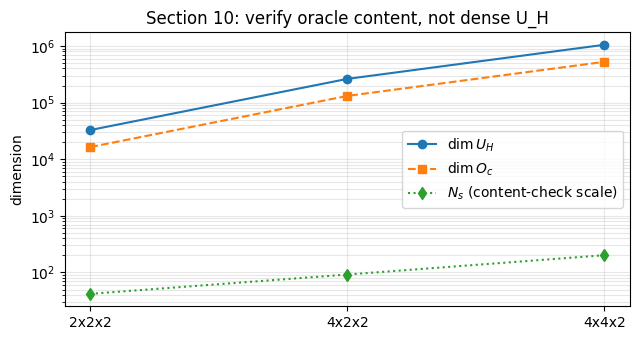

In [21]:
# Content checks avoid materializing U_H — still tied to the small-grid oracle
fp = uh_footprint.set_index(["nx", "ny", "nz"])
print("Hilbert-space sizes (homogeneous):")
for key, row in fp.iterrows():
    print(
        f"  {key[0]}x{key[1]}x{key[2]}: "
        f"U_H dim={int(row['uh_dim']):>8d} (~{row['dense_UH_GB']:.2g} GB), "
        f"O_c dim={int(row['lookup_dim']):>8d} (~{row['dense_Oc_GB']:.2g} GB), "
        f"system dim={int(row['system_dim'])}"
    )

fig, ax = plt.subplots(figsize=(6.5, 3.5))
labels = [f"{a}x{b}x{c}" for a, b, c in fp.index]
x = list(range(len(labels)))
ax.semilogy(x, fp["uh_dim"], "o-", label=r"$\mathrm{dim}\,U_H$")
ax.semilogy(x, fp["lookup_dim"], "s--", label=r"$\mathrm{dim}\,O_c$")
ax.semilogy(x, fp["N_s"], "d:", color="C2", label=r"$N_s$ (content-check scale)")
ax.set_xticks(x, labels)
ax.set_ylabel("dimension")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.set_title("Section 10: verify oracle content, not dense U_H")
plt.tight_layout()
plt.show()


## 11. Time evolution (replace `MatrixExponential`)

Clinic demonstrators used
`SparsePauliOp.from_operator(H.toarray())` + `PauliEvolutionGate(..., MatrixExponential())`, which densifies $H$ into hundreds of Pauli terms even on tiny grids.

**Replacement pipeline (this section):**
1. Assemble $H$ from $U_H$ oracles (`value_table` + $(d,m)\to(i,j)$).
2. Evolve on the **system** register (pad $N\to 2^n$) with a single SciPy / `UnitaryGate` $\mathrm{e}^{-iHt}$ — no Pauli synthesis.
3. Compare to direct sparse $\mathrm{e}^{-iHt}\psi$ on the same $H$.

Full qubitization calling the 15-qubit block-encoding unitary remains future work; here the **access model** is oracle-assembled $H$, matching Aim 1’s “replace MatrixExponential” success criterion.

The $2\times2\times2$ demo below still uses structured Qiskit `UnitaryGate(e^{-iHt})` on the system register for a Pauli-baseline contrast. **Section 12** extends oracle correctness + **sparse-only** evolution to $4\times2\times2$ / $4\times4\times2$ without full `Statevector(O_c)`.


In [22]:
# Homogeneous 2x2x2: oracles already built as `oracle` / `demo` in Section 7–8
rng = np.random.default_rng(0)
psi0 = rng.normal(size=demo["layout"].n_total) + 1j * rng.normal(size=demo["layout"].n_total)
psi0 /= np.linalg.norm(psi0)
t_evol = 1e-6

evo_cmp = compare_evolution_to_direct(oracle, demo["H"], psi0, t_evol)
display(pd.DataFrame([evo_cmp]))

assert evo_cmp["oracle_vs_direct_H"] < 1e-10
assert evo_cmp["qiskit_vs_direct_psi"] < 1e-8

path = evolve_with_assembled_uh(oracle, psi0, t_evol, backend="structured_qiskit")
print("Structured evolution circuit:")
print(f"  system qubits: {path['n_qubits']}  (padded dim {2 ** path['n_qubits']})")
print(f"  ops: {dict(path['circuit'].count_ops())}")
print(
    f"Clinic Pauli baseline on same H: {path['pauli_baseline']['n_pauli_terms']} SparsePauliOp terms "
    f"vs nnz={path['pauli_baseline']['hamiltonian_nnz']}"
)
print(
    f"psi error (structured Qiskit vs direct sparse): {evo_cmp['qiskit_vs_direct_psi']:.2e}"
)


,time,oracle_vs_direct_H,sparse_oracle_vs_direct_psi,n_system,hamiltonian_nnz,qiskit_vs_direct_psi,qiskit_vs_sparse_psi,n_qubits,n_pauli_terms_baseline
0,0.000001,0.0,0.0,42.0,96.0,1.279461e-14,1.279461e-14,6.0,688.0


Structured evolution circuit:
  system qubits: 6  (padded dim 64)
  ops: {'state_preparation': 1, 'unitary': 1}
Clinic Pauli baseline on same H: 688 SparsePauliOp terms vs nnz=96
psi error (structured Qiskit vs direct sparse): 1.28e-14


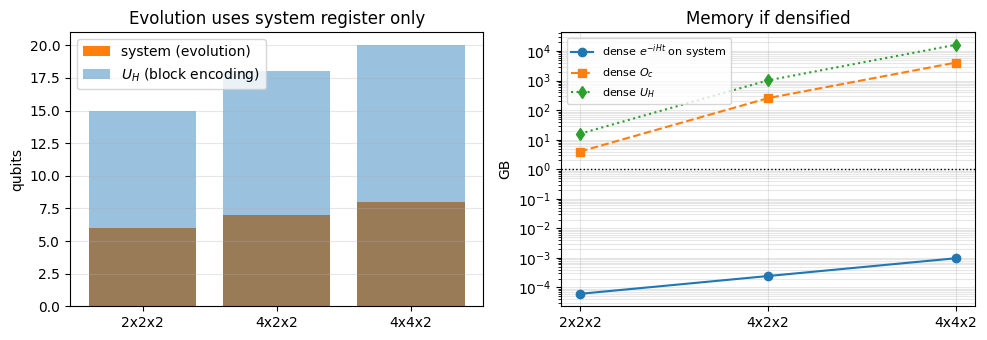

This run: structured evolution on 6 system qubits; Pauli baseline would use 688 terms for nnz=96.
Larger grids: keep sparse expm_multiply / oracle H; do not densify O_c or U_H.


In [23]:
# System evolution vs full U_H: 2x2x2 is feasible; 4x4x2 dense paths are not
fp = uh_footprint.copy()
fp["label"] = [f"{r.nx}x{r.ny}x{r.nz}" for r in fp.itertuples()]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].bar(fp["label"], fp["n_system"], color="C1", label="system (evolution)")
ax[0].bar(fp["label"], fp["n_qubits_uh"], color="C0", alpha=0.45, label=r"$U_H$ (block encoding)")
ax[0].set_ylabel("qubits")
ax[0].legend()
ax[0].grid(True, axis="y", alpha=0.3)
ax[0].set_title("Evolution uses system register only")

ax[1].semilogy(fp["label"], fp["dense_expm_GB"], "o-", label=r"dense $e^{-iHt}$ on system")
ax[1].semilogy(fp["label"], fp["dense_Oc_GB"], "s--", label=r"dense $O_c$")
ax[1].semilogy(fp["label"], fp["dense_UH_GB"], "d:", label=r"dense $U_H$")
ax[1].axhline(1.0, color="k", ls=":", lw=1)
ax[1].set_ylabel("GB")
ax[1].legend(fontsize=8)
ax[1].grid(True, which="both", alpha=0.3)
ax[1].set_title("Memory if densified")
plt.tight_layout()
plt.show()

print(
    f"This run: structured evolution on {int(evo_cmp['n_qubits'])} system qubits; "
    f"Pauli baseline would use {int(evo_cmp['n_pauli_terms_baseline'])} terms "
    f"for nnz={int(evo_cmp['hamiltonian_nnz'])}."
)
print(
    "Larger grids: keep sparse expm_multiply / oracle H; "
    "do not densify O_c or U_H."
)


## 12. Larger-grid oracle correctness + sparse evolution

Section 7 showed that **full** `Statevector(O_c)` is impractical beyond $2\times2\times2$. This section keeps going on $4\times2\times2$ / $4\times4\times2$ by:

1. **Oracle correctness without full SV** — map coverage, MCX gate-count structure, and classical simulation of the same controlled-XOR gates.
2. **Sparse system evolution** — assemble $H$ from oracles and evolve with `expm_multiply(-iHt,\psi)` on the $N_s$-dimensional system register (no dense $U_H$, no Pauli synthesis).

This is the scalable laptop path for §§7–11 physics checks; full qubitization of $U_H$ remains future work.

### Output columns

| Column | Meaning |
|--------|---------|
| `N_s`, `nnz` | System DOFs and nonzero entries of $H$ |
| `n_lookup`, `n_qubits_uh` | Lookup / full $U_H$ qubit counts |
| `map_ok`, `circuit_ok` | Staggered maps + MCX structure/bit-checks passed |
| `sv_spot_used` | Whether optional Qiskit Statevector spot-checks ran (`n_lookup ≤ 14`, to turn it off set `max_sv_lookup_qubits=0`) |
| `O_c_size`, `O_r_size` | MCX gate counts in real index oracles |
| `recon_err`, `odata_amp_err` | Reconstruction / $O_{\mathrm{data}}$ amplitude errors |
| `H_err`, `psi_err_sparse` | $\|H_{\mathrm{oracle}}-H\|_{\max}$ and $\|\|\psi_{\mathrm{oracle}}-\psi_{\mathrm{direct}}\|\|_2$ |
| `wall_seconds` | Total time for that grid’s full §12 pipeline |
| `ok` | All checks passed |


,nx,ny,nz,N_s,nnz,n_lookup,n_qubits_uh,map_ok,circuit_ok,sv_spot_used,O_c_size,O_r_size,recon_err,odata_amp_err,H_err,psi_err_sparse,wall_seconds,ok
0,2,2,2,42,96,14,15,True,True,True,216,244,0.0,2.864375e-14,0.0,0.0,3.702019,True
1,4,2,2,92,240,17,18,True,True,False,702,664,0.0,2.231548e-14,0.0,0.0,1.778692,True
2,4,4,2,202,592,19,20,True,True,False,2107,2186,0.0,2.309264e-14,0.0,0.0,2.102582,True


All grids OK: maps + MCX structure/bit-checks + Im(H)/α recon + sparse oracle evolution vs clinic H.
SV spot-checks used only where n_lookup ≤ 14: {'2x2x2': True, '4x2x2': False, '4x4x2': False}


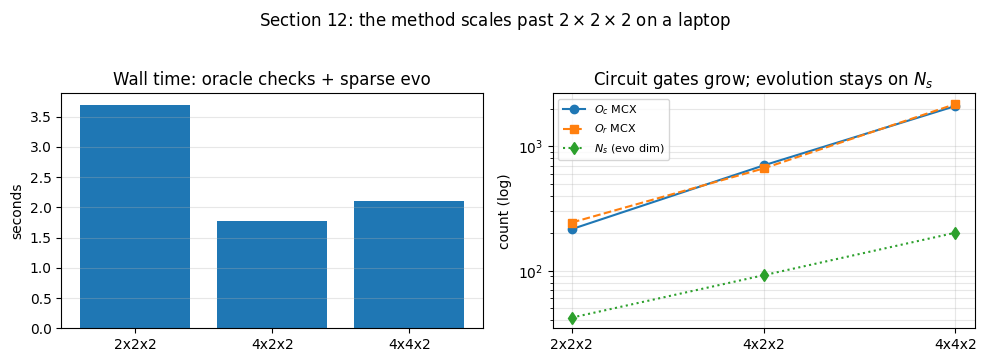

psi errors: [0.0, 0.0, 0.0]  |  H errors: [0.0, 0.0, 0.0]


In [24]:
# Larger grids without full Statevector(O_c) / dense U_H
larger = run_larger_grid_oracle_and_sparse_evolution(
    ((2, 2, 2), (4, 2, 2), (4, 4, 2)),
    add_fractures=False,
    time=1e-6,
    spot_checks=8,
    include_qiskit=False,          # system sparse expm only
    include_pauli_baseline=False,  # skip SparsePauliOp densify
)
display(larger)

assert larger["ok"].all(), larger.loc[~larger["ok"]]
print(
    "All grids OK: maps + MCX structure/bit-checks + Im(H)/α recon + "
    "sparse oracle evolution vs clinic H."
)
print(
    "SV spot-checks used only where n_lookup ≤ 14:",
    dict(zip(larger.apply(lambda r: f"{r.nx}x{r.ny}x{r.nz}", axis=1), larger["sv_spot_used"])),
)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
labels = [f"{r.nx}x{r.ny}x{r.nz}" for r in larger.itertuples()]
x = list(range(len(labels)))
ax[0].bar(x, larger["wall_seconds"], color="C0")
ax[0].set_xticks(x, labels)
ax[0].set_ylabel("seconds")
ax[0].set_title("Wall time: oracle checks + sparse evo")
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].plot(x, larger["O_c_size"], "o-", label=r"$O_c$ MCX")
ax[1].plot(x, larger["O_r_size"], "s--", label=r"$O_r$ MCX")
ax[1].plot(x, larger["N_s"], "d:", color="C2", label=r"$N_s$ (evo dim)")
ax[1].set_xticks(x, labels)
ax[1].set_yscale("log")
ax[1].set_ylabel("count (log)")
ax[1].legend(fontsize=8)
ax[1].grid(True, which="both", alpha=0.3)
ax[1].set_title(r"Circuit gates grow; evolution stays on $N_s$")
fig.suptitle("Section 12: the method scales past $2\\times2\\times2$ on a laptop", y=1.02)
plt.tight_layout()
plt.show()

print(
    f"psi errors: {larger['psi_err_sparse'].tolist()}  |  "
    f"H errors: {larger['H_err'].tolist()}"
)
